# Netflix Subscriber Churn Analysis

### Summary

#### Overview
This analysis identifies the key drivers of subscriber churn for a Netflix-style streaming service and builds a predictive model to flag at- customers before they cancel. The goal is to provide an actionable, interpretable tool for targeted retention: to better understand *why* customers leave and *who* to prioritise.

---

#### The Model
A **Logistic Regression** model was selected for its interpretability. Unlike black-box approaches, logistic regression produces odds ratios for each feature, meaning we can see exactly how much each factor increases or decreases a customer's likelihood of churning, and communicate that clearly to non-technical stakeholders.

The model achieves a **ROC AUC of 0.822** on held-out test data, indicating strong discriminatory power between churners and non-churners. A F2-optimal classification threshold was applied to prioritise catching churners over avoiding false alarms, reflecting the business reality that a missed churner costs more than an unnecessary retention contact.

---

#### Key Findings
**The single strongest churn signal is inactivity.**
Customers who have not logged in for 31–60 days are nearly **5× more likely to churn** than recently active customers. Those lapsed 8–30 days have **63% higher odds** of churning. Login recency is observable in real time, making it the most immediately actionable retention trigger available.

**Payment method is a strong secondary signal.**
Customers paying by **Gift Card or Crypto** have approximately **33–34% higher odds** of churning than those on recurring payment methods. These customers are likely trialling the service without a long-term payment commitment.
    
**Multi-profile accounts are significantly stickier.**
Each additional profile on an account reduces churn odds by approximately **37%**. Single-profile accounts are meaningfully more at risk.

**Higher subscription tiers churn less.**
Premium subscribers churn at lower rates than basic subscribers, reflecting greater financial investment and likely greater engagement with the service.
                                           
---

#### Data Notes
Two variables, **avg_watch_time_per_day** and **watch_hours**, were excluded from the analysis before feature selection on the basis of likely temporal leakage. Customers in the bottom quartile of watch time churned at a rate of 93.8% compared to an overall rate of ~51%, indicating near-perfect separation that is inconsistent with a genuine predictive relationship and strongly suggests these variables were measuring behaviour after the churn decision had already been made rather than predicting it. watch_hours was additionally excluded because its unit of measurement and aggregation timeframe were not documented in the data dictionary, making any leakage assessment impossible to verify. Including either variable would have produced an artificially inflated model that would not generalise to production data.  

---
    
#### Recommended Actions

| Priority | Segment | Action |
|---|---|---|
| 1 | Inactive 31–60 days | Automated re-engagement campaign — personalised recommendations, new content alerts, or limited discount offer |
| 2 | Lapsed 8–30 days | Lighter-touch engagement — push notifications or email prompts before crossing the critical inactivity threshold |
| 3 | Gift Card / Crypto users | Prompt conversion to a recurring payment method near the end of their payment period |
| 4 | Single-profile accounts | Encourage additional profile creation — family and household accounts retain at significantly higher rates |
| 5 | Basic tier subscribers | Targeted upgrade offers — premium subscribers churn less and generate more revenue |

---

#### Highest Risk Customer Profile
The model identifies the following combination as the highest churn risk segment:

> *A customer inactive for 31–60 days, paying by gift card or crypto, with a single 
> profile on the lowest subscription tier*

This segment should be the first target of any retention programme.

### Importing the Data Set and Establishing SQL/DuckDB Connection

In [1]:
import duckdb
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency
import seaborn as sns
import matplotlib.pylab as plt
from matplotlib import pyplot
import math
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, precision_recall_curve, fbeta_score)
from sklearn.calibration import calibration_curve

In [3]:
# # Create a persistent connection and register df as a table
con = duckdb.connect()
con.execute("CREATE TABLE netflix AS SELECT * FROM read_csv_auto('netflix.csv')")

In [5]:
pd.set_option('display.max_rows', 50)

In [7]:
test = con.query("""
    SELECT *
    FROM netflix
""").df()
test

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi


### Anomaly Detection and Data Cleaning

In [10]:
Duplicates = con.query("""
    SELECT customer_id, COUNT(*) AS occurrences
    FROM netflix
    GROUP BY customer_id
    HAVING COUNT(*) > 1
    ORDER BY occurrences DESC
""").df()
Duplicates

,customer_id,occurrences


No indexes/duplicate IDs detected

In [13]:
Missing = con.query("SELECT * FROM netflix").df()
Missing = Missing[Missing.isna().any(axis=1)]
Missing

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre


No blank/NaN entries are detected

In [16]:
#creating a bin for age groups to enhance forthcoming EDA
df = con.query("""
    SELECT 
        customer_id,	age, CASE
        WHEN age < 25 THEN 'Under 25'
        WHEN age BETWEEN 25 and 34 then '25 to 34'
        WHEN age BETWEEN 35 and 44 then '35 to 44'
        WHEN age BETWEEN 45 and 54 then '45 to 54'
        WHEN age BETWEEN 55 and 64 then '55 to 64'
        ELSE '65 and Over'
        END AS age_group,
        gender,	subscription_type, watch_hours, last_login_days, region, device, monthly_fee,
        churned, payment_method, number_of_profiles, avg_watch_time_per_day, favorite_genre
    FROM netflix
""").df()
df

,customer_id,age,age_group,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,45 to 54,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,45 to 54,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,25 to 34,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,45 to 54,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,55 to 64,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Under 25,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,65 and Over,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,65 and Over,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,55 to 64,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi


It appears that **avg_watch_time_per_day** and **watch_hours** measure the same thing: time spent watching Netflix, so it is necessary to verify that the readings correspond to the indicated units and that there are no logic breaking entries.

**monthly_fee** and **subscription_type** are also likely numerical and categorical fields for measuring the exact same thing. If so, one of these will be removed prior to feature selection.

In [19]:
#preferred devices by region
Device = con.query("""
    WITH ranked_device as (
        SELECT
            region,
            device,
            COUNT(device) as device_count
        FROM df
        GROUP BY region, device
        )
    SELECT
        region,
        device,
        device_count,
        RANK() OVER (PARTITION BY region ORDER BY device_count DESC) as device_ranking
    FROM ranked_device 
    ORDER BY region, device_ranking
""").df()
Device

,region,device,device_count,device_ranking
0,Africa,Laptop,165,1
1,Africa,TV,164,2
2,Africa,Desktop,161,3
3,Africa,Mobile,160,4
4,Africa,Tablet,153,5
5,Asia,TV,196,1
6,Asia,Laptop,177,2
7,Asia,Desktop,163,3
8,Asia,Tablet,161,4
9,Asia,Mobile,144,5


In [21]:
df_dataquality = con.query("""
        SELECT *,
            CASE
                WHEN avg_watch_time_per_day > 24 THEN 'invalid_daily_hours'
                WHEN avg_watch_time_per_day = watch_hours THEN 'unit_error'
                WHEN avg_watch_time_per_day > watch_hours THEN 'invalid_watch_hours'
                ELSE 'ok'
                END AS data_flag
        FROM df
""").df()
df_dataquality   

,customer_id,age,age_group,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,data_flag
0,a9b75100-82a8-427a-a208-72f24052884a,51,45 to 54,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,ok
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,45 to 54,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,ok
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,25 to 34,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,ok
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,45 to 54,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,ok
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,55 to 64,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Under 25,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama,ok
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,65 and Over,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary,ok
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,65 and Over,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action,ok
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,55 to 64,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi,ok


In [23]:
red_flags = con.query("""
    SELECT 
        data_flag, COUNT(*)
    FROM df_dataquality 
    GROUP BY data_flag
""").df()
red_flags

,data_flag,count_star()
0,ok,4917
1,unit_error,73
2,invalid_daily_hours,10


We will remove all entries where avg_time_watched_per_day is greater than 24, as this is not possible. There are also over 70 entries where the avg_watch_time_per_day and watch_hours values are identical to each other. This represents unit confusion or data entry errors. For consistency, we will remove all of these. The clean data that will move forward for further analysis will drop 83 entries total.

There are no entries detected where avg_watch_time_per_day is greater than watch_hours.

For feature selection, we will also choose avg_watch_time_per_day instead of watch_hours. This is because the former has more clarity regarding the measured time frame. watch_hours is unclear about this and the data dictionary for the sample data set does not specify the measurement.

In [26]:
#Removing the invalid and unit_error entries and creating a clean netflix churn dataframe to be used for EDA and subsequent analysis.
clean_df = con.query("""
    SELECT * 
    FROM df_dataquality
    WHERE data_flag = 'ok'
""").df()
clean_df

,customer_id,age,age_group,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,data_flag
0,a9b75100-82a8-427a-a208-72f24052884a,51,45 to 54,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,ok
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,45 to 54,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,ok
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,25 to 34,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,ok
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,45 to 54,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,ok
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,55 to 64,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4912,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Under 25,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama,ok
4913,18779bcb-ba2b-41da-b751-e70b812061ec,67,65 and Over,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary,ok
4914,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,65 and Over,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action,ok
4915,7b0ad82d-6571-430e-90f4-906259e0e89c,59,55 to 64,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi,ok


In [28]:
Outcome = con.query("""
    SELECT
        churned, COUNT(*)
    FROM clean_df
    GROUP BY churned
""").df()
Outcome

,churned,count_star()
0,0,2405
1,1,2512


Our variable of interest is almost evenly distributed for churn and non-churned customers. There is no class imbalance and therefore no need to adjust for this in forthcoming analysis.

In [31]:
clean_df.info()
#data types seem appropriate for nature of corresponding field. customer_id is labeled object because they contain letters and digits.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4917 entries, 0 to 4916
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             4917 non-null   object 
 1   age                     4917 non-null   int64  
 2   age_group               4917 non-null   object 
 3   gender                  4917 non-null   object 
 4   subscription_type       4917 non-null   object 
 5   watch_hours             4917 non-null   float64
 6   last_login_days         4917 non-null   int64  
 7   region                  4917 non-null   object 
 8   device                  4917 non-null   object 
 9   monthly_fee             4917 non-null   float64
 10  churned                 4917 non-null   int64  
 11  payment_method          4917 non-null   object 
 12  number_of_profiles      4917 non-null   int64  
 13  avg_watch_time_per_day  4917 non-null   float64
 14  favorite_genre          4917 non-null   

In [33]:
clean_df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,4917.000000,4917.000000,4917.000000,4917.000000,4917.000000,4917.000000,4917.000000
mean,43.848078,11.649575,30.597315,13.692664,0.510881,3.023998,0.698591
std,15.477730,11.967138,17.239085,3.693597,0.499932,1.414585,1.363126
min,18.000000,0.010000,1.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.350000,16.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.010000,31.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,46.000000,17.990000,1.000000,4.000000,0.690000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,18.750000


The continuous variables show meaningful variation. **age** ranges from 18 to 70 (mean 43.8), **last_login_days** spans 1 to 60 days (mean 30.6), **monthly_fee** clusters at three price points between 8.99 and 17.99, and **number_of_profiles** ranges from 1 to 5 (mean 3.0). The wide spread in **watch_hours** (0.01 to 110.4, std 11.97) and **avg_watch_time_per_day** (0.00 to 18.75) relative to their medians of 8.01 and 0.29 respectively suggests right-skewed distributions with extreme high-end values.

### Exploratory Data Analysis and Further Data Set Refinement


#### Examining the spread of numerical variables

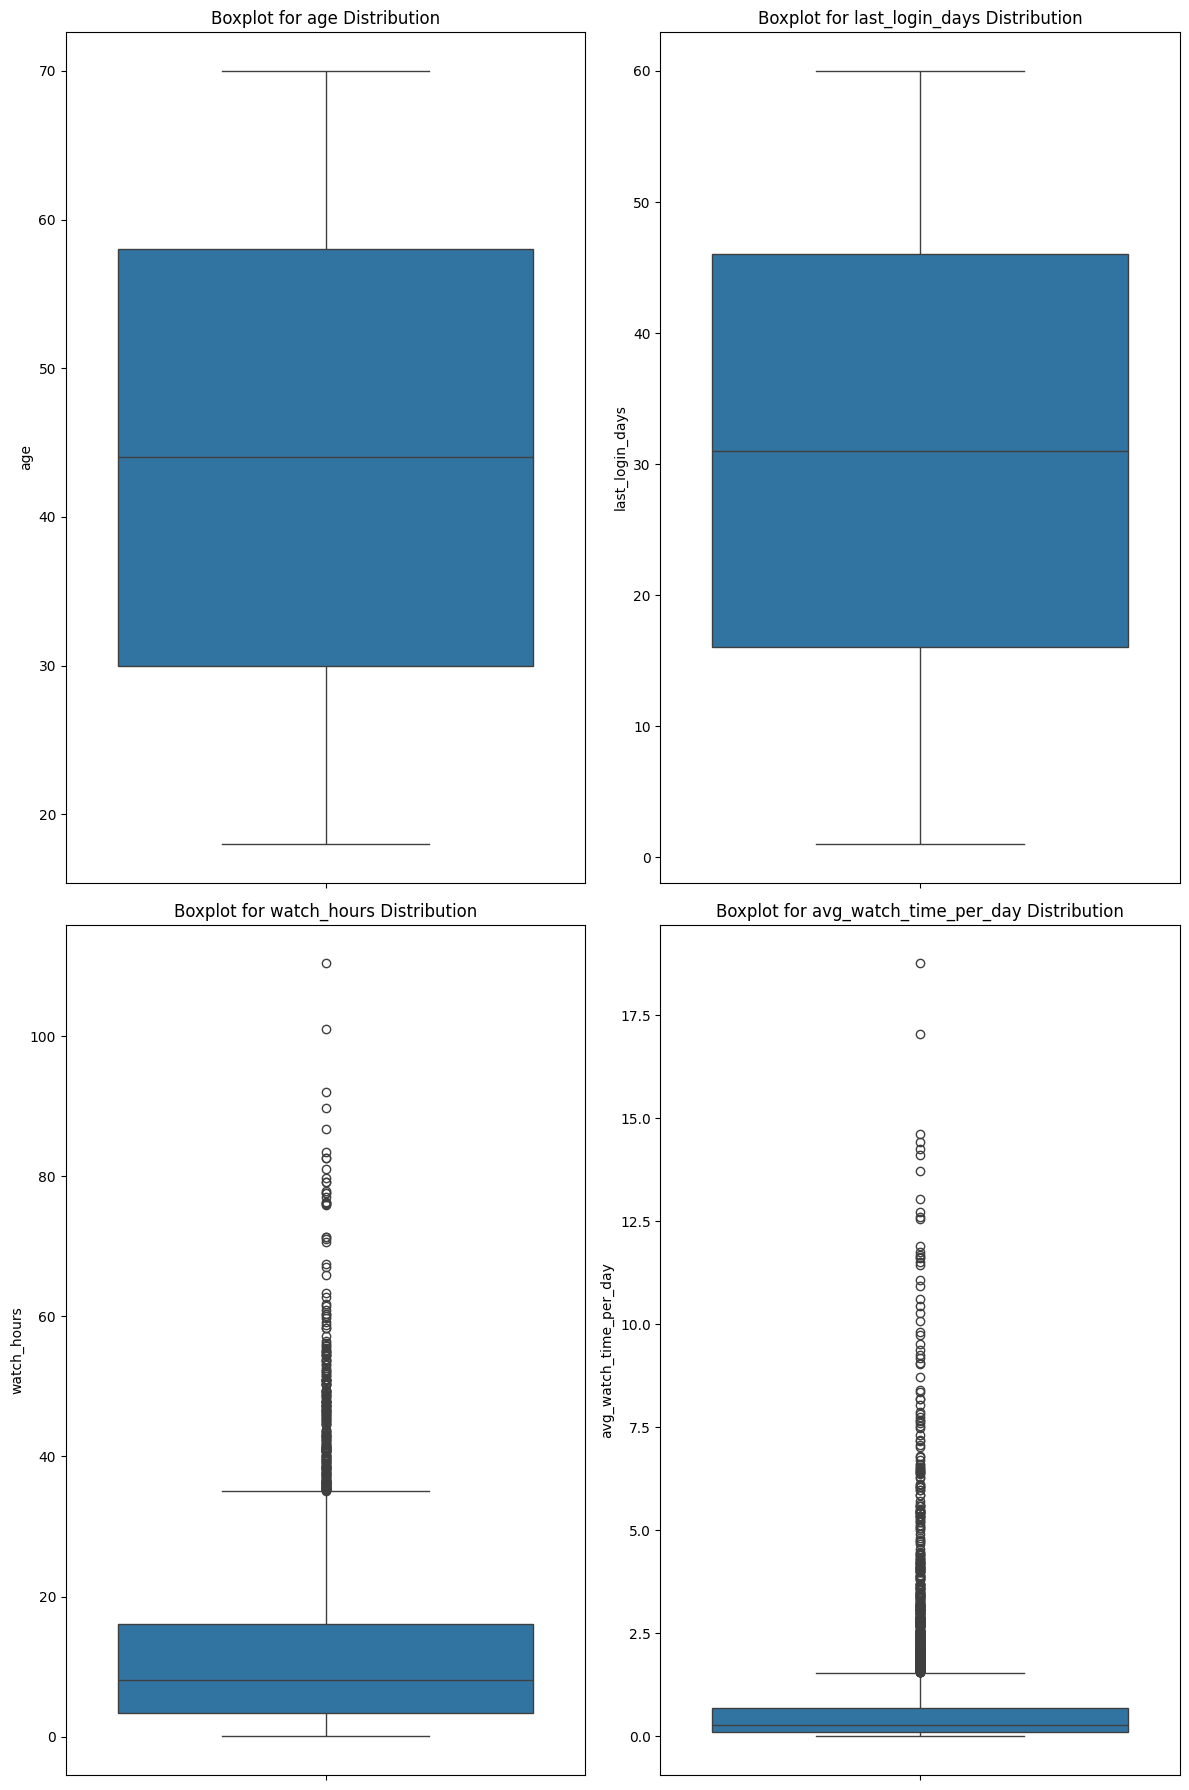

In [37]:
#Box Plots for continuous variables
fig, axes = plt.subplots(2, 2, figsize=(12, 18))
num_vars = ['age', 'last_login_days', 'watch_hours', 'avg_watch_time_per_day',] 
          #  'number_of_profiles', 'monthly_fee']

for i, var in enumerate(num_vars):
    row = i // 2
    col = i % 2
    sns.boxplot(y=clean_df[var], ax=axes[row, col])
    axes[row, col].set_title(f"Boxplot for {var} Distribution")

plt.tight_layout()
plt.show()

No outliers for age or last_login_days. Both are symmetrically distributed, as shown in the previous description table.

The only outliers belong to the time watched variables. Time spent watching the subscription service is likely highly correlated with churn, so we will revisit during univariate analysis against churn/no churn. In all likelihood, since **avg_watch_time_per_day** and **watch_hours** both represent the same essential measure (time spent watching Netflix), only one should be considered for feature selection so that collinear variables are not factored into the predictive model.

#### Examining the spread of Categorical and Ordinal variables

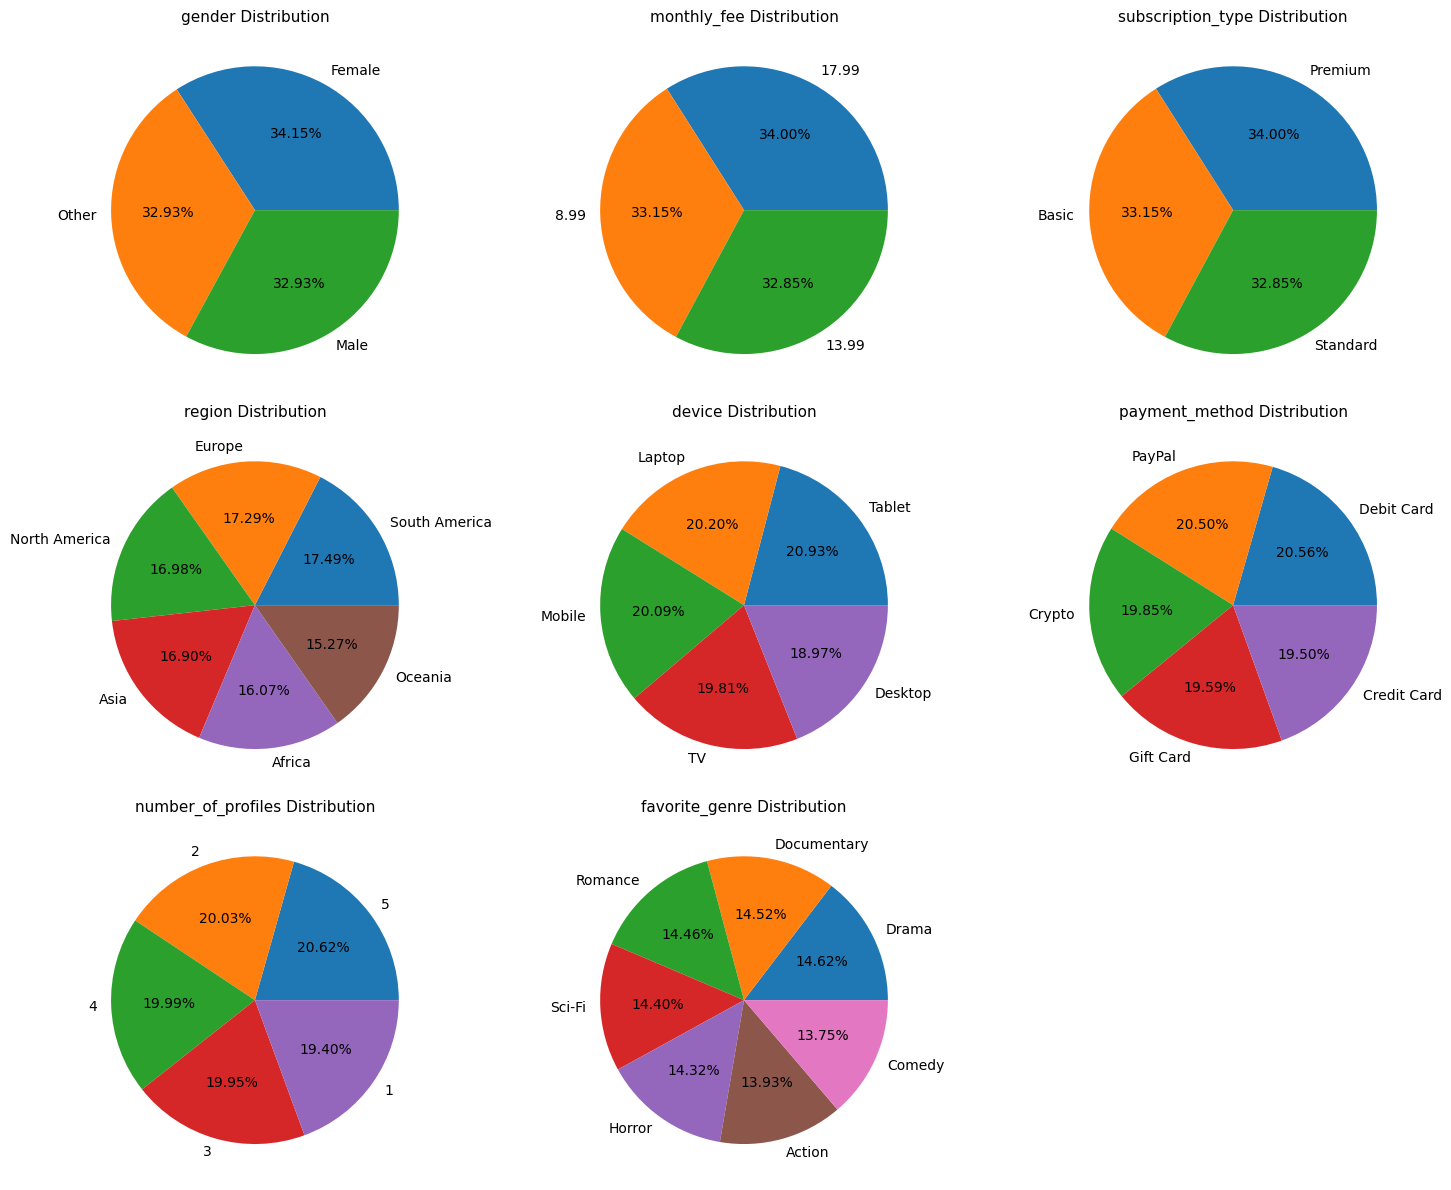

In [41]:
cat_vars = ['gender', 'monthly_fee', 'subscription_type', 'region', 'device', 'payment_method', 'number_of_profiles', 'favorite_genre']

n_cols = 3
n_rows = math.ceil(len(cat_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    counts = clean_df[var].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%0.2f%%')
    axes[i].set_title(f"{var} Distribution", fontsize=11)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

All categorical and ordinal fields are approximately evenly distributed across categories, with no single category exceeding a 2 percentage point share difference.

#### Univariate and Multivariate Relationships with Customer Churn

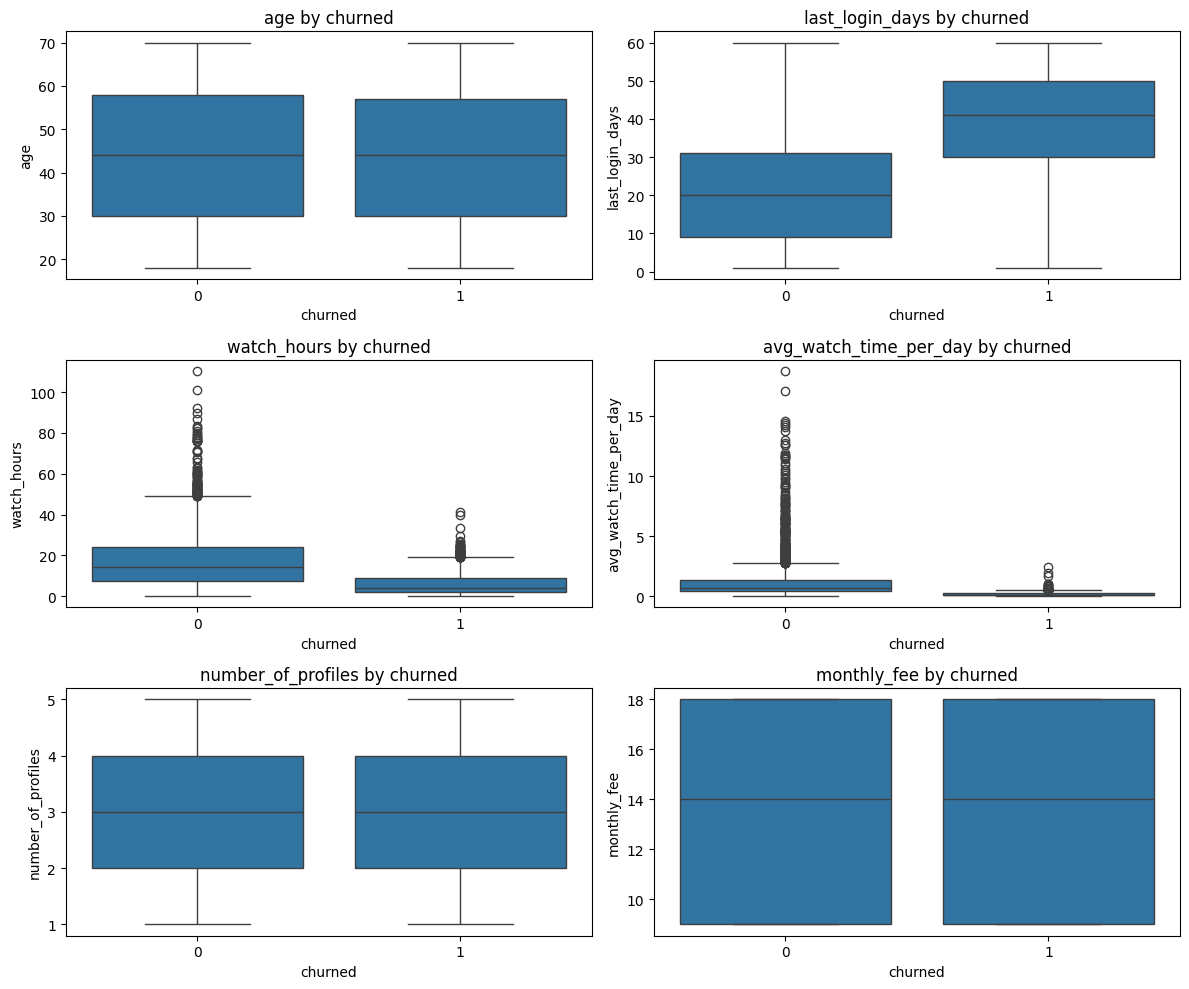

In [45]:
x_vars = ['age', 'last_login_days', 'watch_hours', 'avg_watch_time_per_day', 'number_of_profiles', 'monthly_fee']  # different x variables
y_var = 'churned'

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Flatten axes array so we can loop easily
axes = axes.flatten()

for ax, x in zip(axes, x_vars):
    sns.boxplot(x=y_var, y=x, data=clean_df, ax=ax)
    ax.set_title(f'{x} by {y_var}')

for ax in axes[len(x_vars):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

For **watch_hours** and **avg_watch_time_per_day**, the near-perfect separation between churners and non-churners clearly stands out. The churned group is clustered almost entirely at near-zero watch time while the non-churned group is clustered at well above this and heavily represented in extreme outlier values.

**last_login_days** also shows considerable separation between churners and non-churners. All other continuous variables show no perceptable distribution differences between churners and non-churners. 

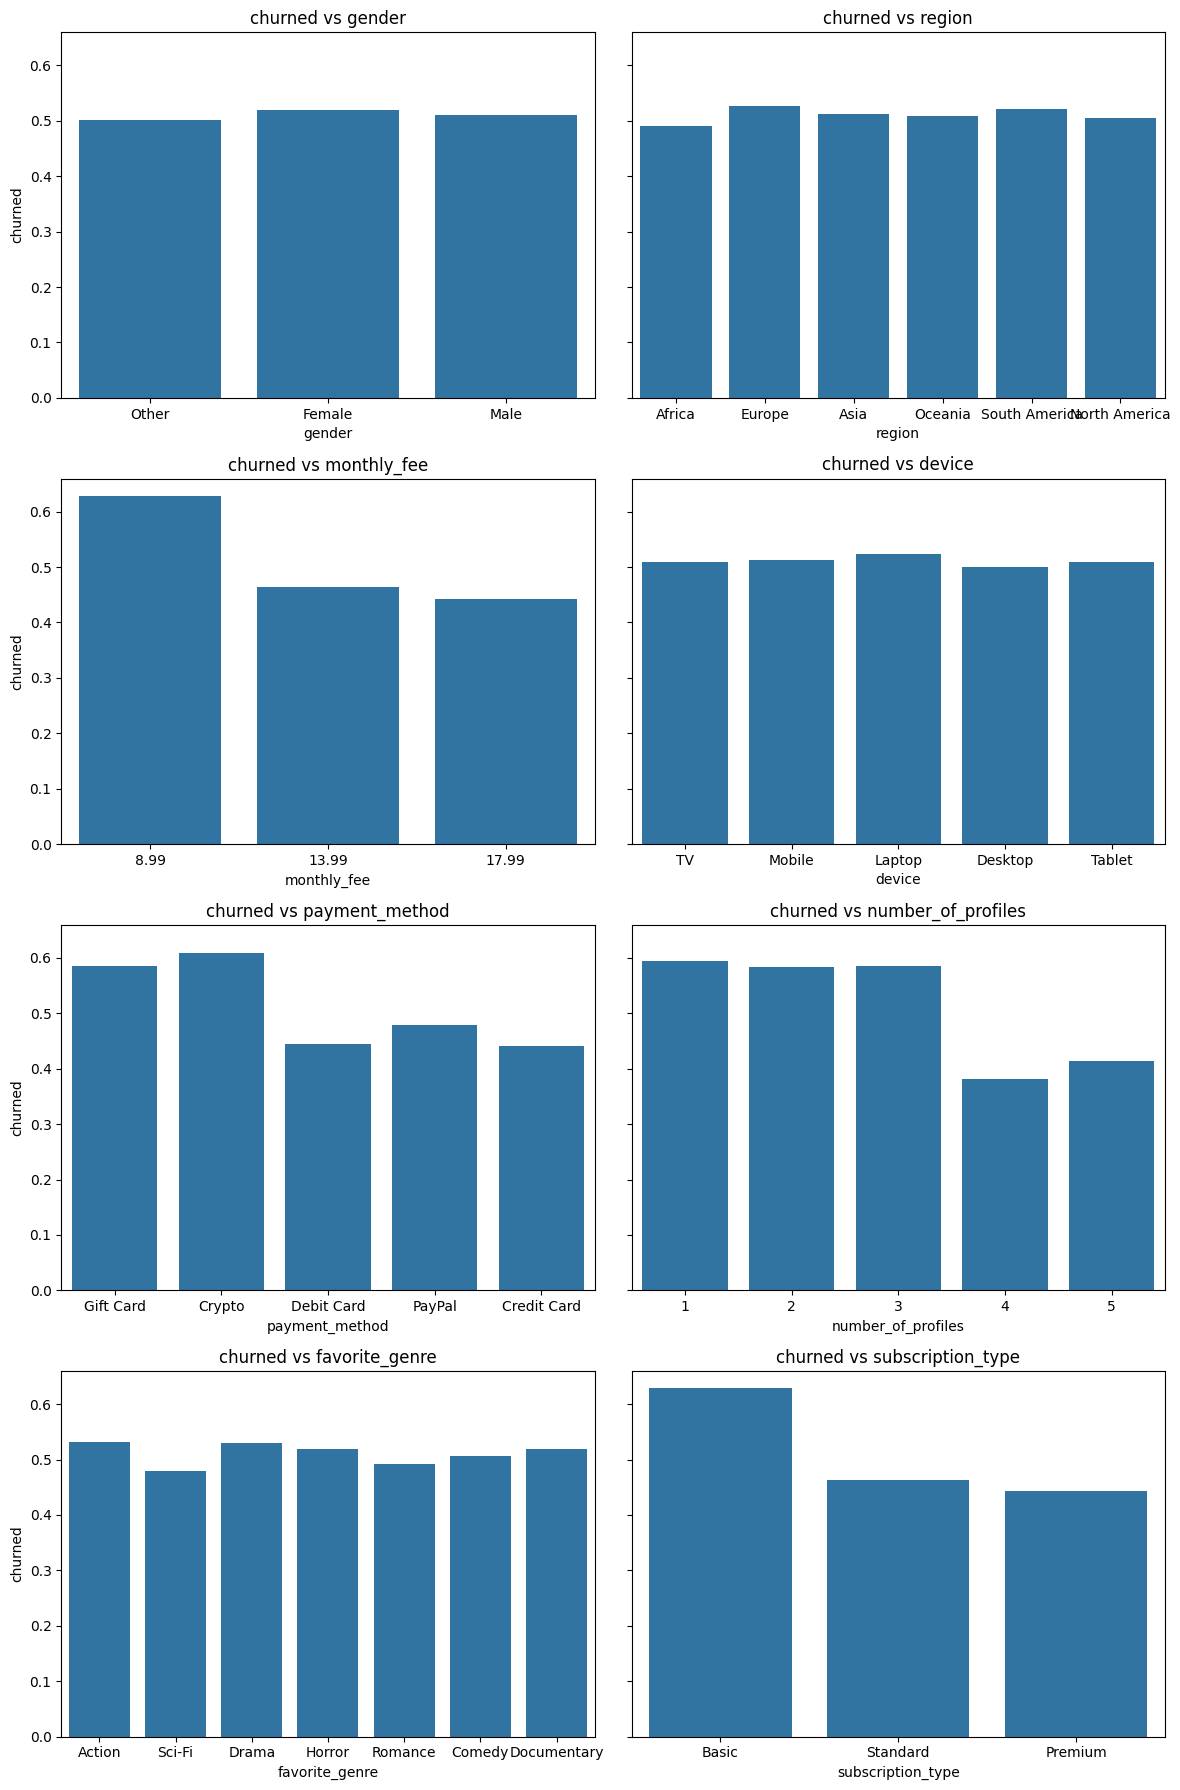

In [48]:
x_vars = ['gender', 'region', 'monthly_fee', 'device', 'payment_method', 'number_of_profiles', 'favorite_genre', 'subscription_type']						
y_var = 'churned'

fig, axes = plt.subplots(4, 2, figsize=(12, 18), sharey=True)

# Flatten axes array so we can loop easily
axes = axes.flatten()

# Loop over x variables and plot
for ax, x in zip(axes, x_vars):
    sns.barplot(x=x, y=y_var, data=clean_df, errorbar=None, ax=ax)
    ax.set_title(f'{y_var} vs {x}')

# Hide any unused subplots (in case number of vars < total slots)
for ax in axes[len(x_vars):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

For categorical and ordinal variables, specific **region**, **gender**, **favorite_genre**, and **device** demonstrate no meaningful association with churn.

The following conditions have a noticeable association with higher churn likelihood:
 - Having 1, 2, or 3 **number_of_profiles** (~0.6) relative to 4 (<0.4) or 5 (<.45)
 - Gift card (>0.55) or Crypto (>0.6) **payment_methods** relative to other means of payment (<0.5)
 - Basic **subscription_types** (+0.6) relative to standard and premium (<0.5)
 - 8.99 **monthly_fee** relative to the other monthly fees. Reflects the exact same relationship as subscription types.

#### Churn Rate by Customer Segment

Churn likelihoods and counts are examined across combinations of gender, age group, region, and other features to identify high-risk customer segments. Unlike univariate analysis which examines each variable in isolation, this approach surfaces interaction effects. For example, whether the elevated churn risk associated with a particular age group is consistent across all regions or concentrated in specific geographies.

In [53]:
#preliminary sorting of combinations of explanatory variables and relationship with customer churn (1.0 churn percent = certain churn)
churn_factors = con.query("""
    SELECT
        gender,
        age_group,
        region,
        COUNT(*) as customer_count,
        ROUND(AVG(churned), 3) as churn_percent,
        SUM(churned) as churn_count
    FROM clean_df
    GROUP BY gender, age_group, region
    ORDER BY churn_percent DESC
""").df()
churn_factors

,gender,age_group,region,customer_count,churn_percent,churn_count
0,Female,45 to 54,North America,39,0.718,28.0
1,Male,45 to 54,Oceania,40,0.700,28.0
2,Male,65 and Over,Oceania,27,0.667,18.0
3,Female,25 to 34,Oceania,51,0.647,33.0
4,Other,45 to 54,Asia,57,0.632,36.0
...,...,...,...,...,...,...
103,Female,35 to 44,Africa,59,0.407,24.0
104,Male,55 to 64,Asia,55,0.400,22.0
105,Other,35 to 44,North America,43,0.395,17.0
106,Female,55 to 64,Africa,51,0.392,20.0


In [55]:
Grouped = con.query("""
    SELECT
        gender,
        age_group,
        region,
        monthly_fee,
        COUNT(customer_id) as customer_count,
        ROUND(AVG(churned),3) as churn_pcnt,
        SUM(churned) as churn_count
    FROM clean_df
    GROUP by gender, region, monthly_fee, age_group
    HAVING customer_count > 10
    ORDER BY churn_pcnt DESC
""").df()
Grouped

,gender,age_group,region,monthly_fee,customer_count,churn_pcnt,churn_count
0,Male,45 to 54,Africa,8.99,12,1.000,12.0
1,Male,Under 25,North America,8.99,12,0.917,11.0
2,Other,Under 25,Asia,8.99,18,0.889,16.0
3,Male,25 to 34,Asia,8.99,17,0.882,15.0
4,Male,Under 25,Europe,8.99,13,0.846,11.0
...,...,...,...,...,...,...,...
266,Female,Under 25,Europe,17.99,14,0.214,3.0
267,Female,35 to 44,Africa,17.99,14,0.214,3.0
268,Male,45 to 54,Africa,17.99,21,0.190,4.0
269,Other,35 to 44,Oceania,17.99,14,0.143,2.0


#### Churn Rate Separation by Feature: Continuous and Categorical Variables

For continuous features, churn rate is compared between customers in the bottom 25% and top 25% of each variable's distribution. For categorical features, churn rate is compared across each category level. In both cases a large difference in churn rates between groups indicates strong separation between churners and non-churners and flags the feature for closer investigation — either as a genuine predictor or as a potential proxy variable subject to leakage. For continuous features a difference exceeding 0.40 between quartile groups is considered high separation, while for categorical features any single category with a churn rate near 0% or 100% warrants particular scrutiny regardless of the overall spread.

In [59]:
# Check churn rate at bottom and top quartiles of each continuous feature
continuous_features = ['avg_watch_time_per_day', 'watch_hours', 
                        'last_login_days', 'age', 'number_of_profiles', 'monthly_fee']

for col in continuous_features:
    q25 = clean_df[col].quantile(0.25)
    q75 = clean_df[col].quantile(0.75)
    low_churn  = clean_df[clean_df[col] <= q25]['churned'].mean()
    high_churn = clean_df[clean_df[col] >= q75]['churned'].mean()
    print(f"{col}:")
    print(f"  Bottom 25% churn rate: {low_churn:.3f}")
    print(f"  Top 25% churn rate:    {high_churn:.3f}")
    print(f"  Difference:            {abs(high_churn - low_churn):.3f}")
    print()

avg_watch_time_per_day:
  Bottom 25% churn rate: 0.938
  Top 25% churn rate:    0.008
  Difference:            0.930

watch_hours:
  Bottom 25% churn rate: 0.871
  Top 25% churn rate:    0.133
  Difference:            0.738

last_login_days:
  Bottom 25% churn rate: 0.212
  Top 25% churn rate:    0.755
  Difference:            0.543

age:
  Bottom 25% churn rate: 0.517
  Top 25% churn rate:    0.494
  Difference:            0.023

number_of_profiles:
  Bottom 25% churn rate: 0.589
  Top 25% churn rate:    0.398
  Difference:            0.191

monthly_fee:
  Bottom 25% churn rate: 0.628
  Top 25% churn rate:    0.443
  Difference:            0.186



**last_login_days** has a sizable Q1-Q3 difference as well, but it is much lower and the variable is more intuitively a predictor of churn. Customers who have not logged in in a long time would seem more prone to cancel their subscriptions.

**avg_watch_time_per_day** tells a different story. Customers in the bottom 25% of watch time churn at 93.8% while the top 25% churn at only 0.8%. This is essentially a perfect separator: near-zero watch time means almost certain churn, high watch time means almost certain retention. This is not a predictive relationship; it is a proxy for the outcome rather than a predictor of it. The most likely explanation is temporal leakage — near-zero daily watch time may reflect viewing activity recorded on accounts that had already been cancelled, meaning the variable is measuring a consequence of churn rather than a predictor of it. **watch_hours** carries the same risk. It is dropped on this basis and additionally because its unit of measurement and aggregation timeframe are not documented in the data dictionary, making its interpretation and any leakage assessment impossible to verify.              

In [62]:
categorical_features = ['payment_method', 'device', 'favorite_genre', 
                         'region', 'gender', 'subscription_type']

print("Churn rate by category:")
for col in categorical_features:
    churn_by_cat = clean_df.groupby(col)['churned'].agg(['mean', 'count'])
    churn_by_cat.columns = ['churn_rate', 'count']
    churn_by_cat['churn_rate'] = churn_by_cat['churn_rate'].round(3)
    
    max_churn = churn_by_cat['churn_rate'].max()
    min_churn = churn_by_cat['churn_rate'].min()
    diff = round(max_churn - min_churn, 3)
    
    print(f"\n{col} (max-min difference: {diff}):")
    print(churn_by_cat.to_string())

Churn rate by category:

payment_method (max-min difference: 0.168):
                churn_rate  count
payment_method                   
Credit Card          0.441    959
Crypto               0.609    976
Debit Card           0.444   1011
Gift Card            0.586    963
PayPal               0.478   1008

device (max-min difference: 0.023):
         churn_rate  count
device                    
Desktop       0.501    933
Laptop        0.524    993
Mobile        0.513    988
TV            0.508    974
Tablet        0.508   1029

favorite_genre (max-min difference: 0.052):
                churn_rate  count
favorite_genre                   
Action               0.531    685
Comedy               0.506    676
Documentary          0.518    714
Drama                0.530    719
Horror               0.520    704
Romance              0.492    711
Sci-Fi               0.479    708

region (max-min difference: 0.036):
               churn_rate  count
region                          
Africa       

The max-min differences for all categorical variables is low, suggesting no leakage/redundancy/other data quality concerns.

#### Correlation between Explanatory Variables

In [66]:
print(clean_df[['avg_watch_time_per_day', 'watch_hours']].corr())

                        avg_watch_time_per_day  watch_hours
avg_watch_time_per_day                1.000000     0.481641
watch_hours                           0.481641     1.000000


In [68]:
print(pd.crosstab(clean_df['subscription_type'], clean_df['monthly_fee']))

monthly_fee        8.99   13.99  17.99
subscription_type                     
Basic               1630      0      0
Premium                0      0   1672
Standard               0   1615      0


each subscription type maps to exactly one monthly fee value, confirming that monthly_fee and subscription_type are identical in information content. We drop subscription_type because monthly_fee's ordinal/numerical structure will be more helpful during analysis.

##### **Variables to be dropped:**
- avg_watch_time_per_day (leakage/redundancy)
- watch_hours (leakage/redundancy)
- subscription_type (perfect collinearity with monthly_fee)
- age_group (already represented by age)
- customer_id (index, not needed for analysis)
- data_flag (only created and used for data cleaning and EDA)

age failed the t-test and demonstrated negligible Q1-Q3 churn rate difference, and will likely be dropped following the AUC comparison. 

In [72]:
clean_df = clean_df.drop(['customer_id', 'subscription_type', 'watch_hours', 'avg_watch_time_per_day', 'age_group', 'data_flag'], axis=1)

### Statistical Tests

In [75]:
# Chi-square tests — run on original df using pre-encoding categorical columns.
categorical_features = ['gender', 'region', 'device', 'payment_method', 'favorite_genre']

chi2_results = []
for col in categorical_features:
    contingency_table = pd.crosstab(clean_df[col], clean_df['churned'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    chi2_results.append({'feature': col, 'chi2_stat': chi2, 'p_value': p})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_df

,feature,chi2_stat,p_value
3,payment_method,99.904682,1.030714e-20
4,favorite_genre,6.542002,3.652836e-01
0,gender,1.048563,5.919807e-01
1,region,2.635418,7.559769e-01
2,device,1.125624,8.901857e-01


In [77]:
#For ordinal variables, the more rigorous test is the Kruskal-Wallis test rather than Welch's t-test.
#Kruskal-Wallis is the non-parametric equivalent of a one-way ANOVA. It tests whether the distribution of an ordinal variable differs 
#significantly between the churned and non-churned groups without assuming the values are normally distributed or that the intervals between ranks are equal.
ordinal_features = ['monthly_fee', 'number_of_profiles']

kruskal_results = []
for col in ordinal_features:
    group0 = clean_df[clean_df['churned'] == 0][col]
    group1 = clean_df[clean_df['churned'] == 1][col]
    stat, p_value = kruskal(group0, group1)
    kruskal_results.append({'feature': col, 'kruskal_stat': stat, 'p_value': p_value})

kruskal_df = pd.DataFrame(kruskal_results).sort_values('p_value')
kruskal_df

,feature,kruskal_stat,p_value
1,number_of_profiles,125.005284,5.075935e-29
0,monthly_fee,112.695885,2.515439e-26


In [79]:
continuous_features = ['age', 'last_login_days']

t_test_results = []
for col in continuous_features:
    group0 = clean_df[clean_df['churned'] == 0][col]
    group1 = clean_df[clean_df['churned'] == 1][col]
    t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    t_test_results.append({'feature': col, 't_stat': t_stat, 'p_value': p_value})

t_test_df = pd.DataFrame(t_test_results).sort_values('p_value')
t_test_df

,feature,t_stat,p_value
1,last_login_days,-36.253276,7.875530e-255
0,age,0.166554,8.677281e-01


**Multiple Comparison Correction**

Benjamini-Hochberg FDR correction is applied across all three sets of statistical tests to guard against false positives from running multiple simultaneous tests. With only 5 chi-square tests, 2 Kruskal-Wallis tests, and 2 Welch's t-tests, the risk of false positive accumulation is low and the correction is unlikely to change any conclusions.

In [82]:
# ── Chi-square FDR correction ─────────────────────────────────────────────────
raw_p_chi2 = chi2_df['p_value'].values
reject_chi2, p_corrected_chi2, _, _ = multipletests(raw_p_chi2, method='fdr_bh')

chi2_df['p_value_corrected'] = p_corrected_chi2
chi2_df['reject_null']       = reject_chi2
print("Chi-square results with FDR correction:")
print(chi2_df.to_string())

# ── Kruskal-Wallis FDR correction ─────────────────────────────────────────────
raw_p_kruskal = kruskal_df['p_value'].values
reject_kruskal, p_corrected_kruskal, _, _ = multipletests(raw_p_kruskal, method='fdr_bh')

kruskal_df['p_value_corrected'] = p_corrected_kruskal
kruskal_df['reject_null']       = reject_kruskal
print("\nKruskal-Wallis results with FDR correction:")
print(kruskal_df.to_string())

# ── Welch's t-test FDR correction ─────────────────────────────────────────────
raw_p_ttest = t_test_df['p_value'].values
reject_ttest, p_corrected_ttest, _, _ = multipletests(raw_p_ttest, method='fdr_bh')

t_test_df['p_value_corrected'] = p_corrected_ttest
t_test_df['reject_null']       = reject_ttest
print("\nWelch's t-test results with FDR correction:")
print(t_test_df.to_string())

Chi-square results with FDR correction:
          feature  chi2_stat       p_value  p_value_corrected  reject_null
3  payment_method  99.904682  1.030714e-20       5.153570e-20         True
4  favorite_genre   6.542002  3.652836e-01       8.901857e-01        False
0          gender   1.048563  5.919807e-01       8.901857e-01        False
1          region   2.635418  7.559769e-01       8.901857e-01        False
2          device   1.125624  8.901857e-01       8.901857e-01        False

Kruskal-Wallis results with FDR correction:
              feature  kruskal_stat       p_value  p_value_corrected  reject_null
1  number_of_profiles    125.005284  5.075935e-29       1.015187e-28         True
0         monthly_fee    112.695885  2.515439e-26       2.515439e-26         True

Welch's t-test results with FDR correction:
           feature     t_stat        p_value  p_value_corrected  reject_null
1  last_login_days -36.253276  7.875530e-255      1.575106e-254         True
0              age  

All results that were significant before correction remain  significant after. The correction is applied for consistency and methodological rigour rather than necessity.

Across all variables tested, only payment_method, number_of_profiles, monthly_fee, and last_login_days returned statistically significant p-values, indicating these are the only features with a meaningful association with churn that is unlikely to be attributable to chance. These four variables are therefore the primary candidates for inclusion in the final model.

avg_watch_time_per_day and watch_hours would almost certainly also return highly significant p-values given their near-perfect separation of churners and non-churners, but they are excluded from consideration on the basis of likely temporal leakage rather than statistical insignificance

### Encoding

In [84]:
# Create a copy of the original dataframe for encoding. The original df is preserved for EDA visualisations that use string labels.
# Encoding is applied to encoded_df only, which will be used for correlation analysis and modeling.
encoded_df = clean_df.copy()

In [86]:
#Encoding all categorical/non-ordinal variables
encoded_df = pd.get_dummies(encoded_df, 
                            columns=['gender', 'region', 'device', 'payment_method', 'favorite_genre'], 
                            drop_first=True)

# Cast boolean dummy columns to int to avoid dtype issues in sklearn
for col in ['gender', 'region', 'device', 'payment_method', 'favorite_genre']:
    dummy_cols = [c for c in encoded_df.columns if c.startswith(col + '_')]
    encoded_df[dummy_cols] = encoded_df[dummy_cols].astype(int)

In [88]:
#Encoding ordinal variables
#Check unique values first so category order is specified correctly
print("number_of_profiles:", sorted(encoded_df['number_of_profiles'].unique()))
print("monthly_fee:", sorted(encoded_df['monthly_fee'].unique()))

number_of_profiles: [1, 2, 3, 4, 5]
monthly_fee: [8.99, 13.99, 17.99]


In [90]:
oe = OrdinalEncoder(categories=[
    [1, 2, 3, 4, 5],      # number_of_profiles — numeric, ascending
    [8.99, 13.99, 17.99]  # monthly_fee — numeric, ascending
])

encoded_df[['number_of_profiles', 'monthly_fee']] = oe.fit_transform(
    encoded_df[['number_of_profiles', 'monthly_fee']]
)
encoded_df.head()

,age,last_login_days,monthly_fee,churned,number_of_profiles,gender_Male,gender_Other,region_Asia,region_Europe,region_North America,...,payment_method_Crypto,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi
0,51,29,0.0,1,0.0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,47,19,1.0,1,4.0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,1
2,27,10,1.0,0,1.0,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
3,53,12,2.0,1,1.0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,56,13,1.0,1,1.0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [92]:
X = encoded_df.drop('churned', axis=1)
y = encoded_df['churned']

### Assumption Testing

**Assumption 1: No perfect multicollinearity**

In [94]:
vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF':     [variance_inflation_factor(X.values, i) 
                for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data)
print("\nFeatures with VIF > 5 (concern):")
print(vif_data[vif_data['VIF'] > 5])

                       Feature       VIF
0                          age  7.139136
1              last_login_days  3.884092
3           number_of_profiles  2.918895
2                  monthly_fee  2.435933
14               device_Tablet  1.948317
12               device_Mobile  1.923299
11               device_Laptop  1.919533
13                   device_TV  1.912068
18       payment_method_PayPal  1.909063
4                  gender_Male  1.907128
5                 gender_Other  1.904304
10        region_South America  1.903090
16   payment_method_Debit Card  1.900837
7                region_Europe  1.895933
15       payment_method_Crypto  1.894798
8         region_North America  1.885203
6                  region_Asia  1.884466
17    payment_method_Gift Card  1.872940
21        favorite_genre_Drama  1.856817
22       favorite_genre_Horror  1.850350
23      favorite_genre_Romance  1.846807
20  favorite_genre_Documentary  1.840014
24       favorite_genre_Sci-Fi  1.832861
19       favorit

Age is the only variable with a concerning VIF. It means age is not fully independent of the other features; some combination of your other variables (likely something like number_of_profiles or subscription-related features) is carrying overlapping information with age. If age is found to be an important variable to include in the model during feature selection, the age coefficient will need to be interpreted with caution.

**Assumption 2: Linearity of log odds**

In [98]:
#Logistic regression assumes a linear relationship between each continuous feature and the log odds of the outcome — not the outcome itself.
#This is tested with the Box-Tidwell test, which adds an interaction term between each continuous feature and its natural log, 
# and checks whether that interaction is significant.

# Select continuous features only
continuous_features = ['last_login_days', 'age']

X_bt = X[continuous_features].copy()

# Add log-transformed interaction terms
# Small constant added to avoid log(0)
for col in continuous_features:
    X_bt[f'{col}_log'] = X_bt[col] * np.log(X_bt[col].clip(lower=0.001))

X_bt_const = sm.add_constant(X_bt)
bt_model = sm.Logit(y, X_bt_const).fit(disp=0)

print("Box-Tidwell test — interaction term p-values:")
for col in continuous_features:
    pval = bt_model.pvalues[f'{col}_log']
    flag = '*** VIOLATION' if pval < 0.05 else 'OK'
    print(f"  {col}: p = {pval:.4f}  {flag}")

Box-Tidwell test — interaction term p-values:
  last_login_days: p = 0.0001  *** VIOLATION
  age: p = 0.9281  OK


Given the low p value for last_login_days, we will first attempt a log transformation and re-test before considering alternatives.

**Assumption 3: No influential outliers**

Influential observations (Cook's D > 0.0008): 157


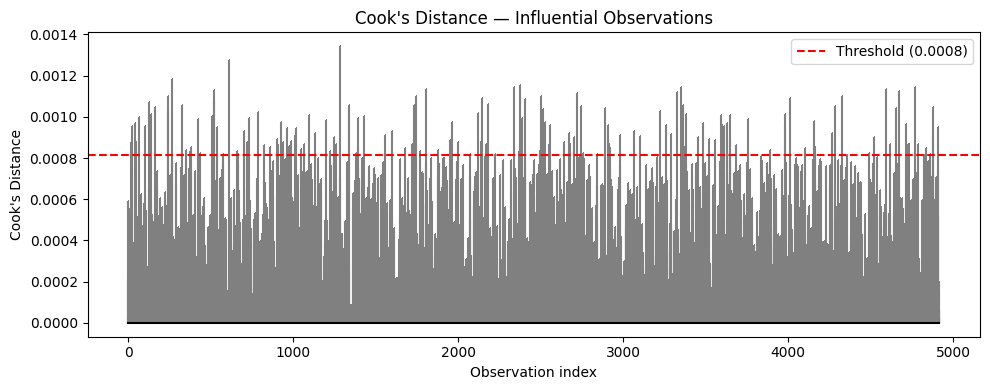

In [100]:
#Cook's Distance measures how much the model's coefficients would change if a particular observation were removed from the training data. 
#It combines two things — how far an observation's predicted value is from the actual value, 
#and how much leverage that observation has on the model's fit. 
#A high Cook's D means that single observation is exerting disproportionate influence on the model.
# Scale the full X for Cook's D — no split needed
# fit_transform on full X is acceptable here because we are not building
# a predictive model, just diagnosing influential observations

scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

X_const = sm.add_constant(X_scaled_full)
logit_model = sm.Logit(y, X_const).fit(disp=0)

influence  = logit_model.get_influence()
cooks_d    = influence.cooks_distance[0]

threshold     = 4 / len(X_scaled_full)
n_influential = (cooks_d > threshold).sum()
print(f"Influential observations (Cook's D > {threshold:.4f}): {n_influential}")

plt.figure(figsize=(10, 4))
plt.stem(cooks_d, markerfmt=',', linefmt='grey', basefmt='black')
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.4f})')
plt.title("Cook's Distance — Influential Observations")
plt.xlabel('Observation index')
plt.ylabel("Cook's Distance")
plt.legend()
plt.tight_layout()
plt.show()

The current plot shows a relatively consistent band of Cook's D values across almost 5,000 observations with no dramatic outliers. It indicates the model's coefficients are not being disproportionately influenced by any individual observation.

**Assumption 4: Sufficient sample size**

In [109]:
#A common rule of thumb is a minimum of 10 events per predictor variable 
n_churners = y.sum()
n_features = X.shape[1]
epp = n_churners / n_features

print(f"Churners (events): {n_churners}")
print(f"Features: {n_features}")
print(f"Events per predictor: {epp:.1f}")

if epp < 10:
    print("WARNING: Below 10 events per predictor — consider reducing features further.")
elif epp < 20:
    print("Acceptable but lean — consider reducing features where possible.")
else:
    print("Sample size is sufficient.")

Churners (events): 2512
Features: 25
Events per predictor: 100.5
Sample size is sufficient.


**Assumption 5: Independence of observations**

Under this assumption, each customer's churn decision should be independent of every other customer's. For a Netflix user dataset this is almost certainly satisfied unless there are household accounts where one person's cancellation triggers another's. For this analysis, it is assumed that this condition does not exist.

##### **Transformations for variables that violated linearity of log odds assumption**

The key effect is that large values get compressed much more than small values. The gap between 1 and 10 (which becomes 0.693 to 2.398) is much smaller after transformation than the gap between 0 and 1. This is precisely what corrects the non-linearity violation — it brings extreme values closer to the centre of the distribution and makes the relationship between the feature and the log odds of churn more linear, 

In [111]:
tr_encoded_df = encoded_df.copy()

In [113]:
tr_encoded_df['last_login_days']= np.log1p(tr_encoded_df['last_login_days'])

tr_encoded_df = tr_encoded_df.rename(columns={
    'last_login_days':        'log_last_login_days'
})

In [115]:
# Define X and y from your cleaned, encoded dataframe
tr_X = tr_encoded_df.drop('churned', axis=1)
tr_y = tr_encoded_df['churned']

In [117]:
#Re-run Box-Tidwell — confirms linearity violation is resolved
continuous_features_updated = ['log_last_login_days', 'age']

X_bt = tr_X[continuous_features_updated].copy()
for col in continuous_features_updated:
    X_bt[f'{col}_log'] = X_bt[col] * np.log(X_bt[col].clip(lower=0.001))

X_bt_const = sm.add_constant(X_bt)
bt_model = sm.Logit(y, X_bt_const).fit(disp=0)

print("Box-Tidwell recheck:")
for col in continuous_features_updated:
    pval = bt_model.pvalues[f'{col}_log']
    flag = '*** VIOLATION' if pval < 0.05 else 'OK'
    print(f"  {col}: p = {pval:.4f}  {flag}")

#Re-run VIF — transformation can occasionally affect multicollinearity
vif_data = pd.DataFrame({
    'Feature': tr_X.columns,
    'VIF':     [variance_inflation_factor(tr_X.values, i)
                for i in range(tr_X.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data)

Box-Tidwell recheck:
  log_last_login_days: p = 0.0000  *** VIOLATION
  age: p = 0.8959  OK
                       Feature        VIF
1          log_last_login_days  11.960220
0                          age   7.625019
3           number_of_profiles   2.966488
2                  monthly_fee   2.456437
14               device_Tablet   1.981876
10        region_South America   1.955353
18       payment_method_PayPal   1.954426
12               device_Mobile   1.954289
11               device_Laptop   1.950385
16   payment_method_Debit Card   1.949642
7                region_Europe   1.949265
13                   device_TV   1.944782
15       payment_method_Crypto   1.937846
8         region_North America   1.932007
4                  gender_Male   1.931863
6                  region_Asia   1.930310
5                 gender_Other   1.925074
17    payment_method_Gift Card   1.917219
21        favorite_genre_Drama   1.910433
22       favorite_genre_Horror   1.899023
23      favorite_genre_Rom

The log transformation **did not resolve** the Box-Tidwell violation for last_login_days. The VIF for last_login_days also increased following the transformation. A closer examination of this fields distribution is required to see if a transformation will actually resolve this issue.

This approach was tested and abandoned; encoded_df remains the working dataframe going forward.

In [119]:
print(encoded_df['last_login_days'].describe())
print(f"\nUnique values: {encoded_df['last_login_days'].nunique()}")
print(f"\nValue counts (top 20):\n{encoded_df['last_login_days'].value_counts().head(20)}")

count    4917.000000
mean       30.597315
std        17.239085
min         1.000000
25%        16.000000
50%        31.000000
75%        46.000000
max        60.000000
Name: last_login_days, dtype: float64

Unique values: 60

Value counts (top 20):
last_login_days
37    102
16    100
46     98
44     96
10     94
53     93
4      93
54     92
26     92
18     91
40     91
2      90
25     90
11     89
27     89
23     89
41     88
39     88
34     88
24     88
Name: count, dtype: int64


The output indicates the problem: last_login_days is approximately uniformly distributed across 1 to 60 days. Look at the value counts: every value from 1 to 60 appears roughly 88–102 times, meaning customers are spread almost evenly across all possible values. No mathematical transformation will fix a Box-Tidwell violation on a uniform distribution because there is no natural curvature to straighten out — the relationship simply isn't suited to being modelled as a continuous linear predictor. Instead, we will turn last_login_days into a categorical variable with distinct bins.

In [122]:
# Bin last_login_days into meaningful engagement categories
bins   = [0, 7, 30, 60]
labels = ['active_1_7d', 'lapsed_8_30d', 'inactive_31_60d']

encoded_df['last_login_segment'] = pd.cut(
    encoded_df['last_login_days'],
    bins=bins,
    labels=labels
)

In [124]:
ct = pd.crosstab(encoded_df['last_login_segment'], encoded_df['churned'])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-square p-value for last_login_segment vs churn: {p:.4f}")
print(f"Minimum expected frequency: {expected.min():.1f}")

Chi-square p-value for last_login_segment vs churn: 0.0000
Minimum expected frequency: 277.3


The significant chi-square result tells you the three segments have meaningfully different churn rates, which means the binned variable is carrying genuine predictive signal.
The argument for keeping the binned version is solid.

##### Adjusting the model to correct for assumption violations

In [128]:
# One-hot encode the bins — drop_first=True to avoid dummy variable trap
encoded_df = pd.get_dummies(
    encoded_df,
    columns=['last_login_segment'],
    drop_first=True,
    dtype=int
)

# Drop the original continuous last_login_days — replaced by dummies
encoded_df = encoded_df.drop(columns=['last_login_days'])

In [130]:
# Redefine X and Y after the change
X = encoded_df.drop('churned', axis=1)
y = encoded_df['churned']

In [132]:
#Re-run Box-Tidwell — confirms linearity violation is resolved
continuous_features_updated = ['age']

X_bt = X[continuous_features_updated].copy()
for col in continuous_features_updated:
    X_bt[f'{col}_log'] = X_bt[col] * np.log(X_bt[col].clip(lower=0.001))

X_bt_const = sm.add_constant(X_bt)
bt_model = sm.Logit(y, X_bt_const).fit(disp=0)

print("Box-Tidwell recheck:")
for col in continuous_features_updated:
    pval = bt_model.pvalues[f'{col}_log']
    flag = '*** VIOLATION' if pval < 0.05 else 'OK'
    print(f"  {col}: p = {pval:.4f}  {flag}")

#Re-run VIF — transformation can occasionally affect multicollinearity
vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF':     [variance_inflation_factor(X.values, i)
                for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data)

Box-Tidwell recheck:
  age: p = 0.9907  OK
                               Feature       VIF
0                                  age  7.298160
25  last_login_segment_inactive_31_60d  4.564356
24     last_login_segment_lapsed_8_30d  3.685493
2                   number_of_profiles  2.946099
1                          monthly_fee  2.445499
13                       device_Tablet  1.963530
11                       device_Mobile  1.937201
10                       device_Laptop  1.933243
12                           device_TV  1.931380
15           payment_method_Debit Card  1.929892
17               payment_method_PayPal  1.927024
9                 region_South America  1.924262
4                         gender_Other  1.916124
3                          gender_Male  1.915688
6                        region_Europe  1.914299
14               payment_method_Crypto  1.907790
5                          region_Asia  1.899987
7                 region_North America  1.896964
16            payment_meth

In [134]:
n_churners = y.sum()
n_features = X.shape[1]
epp = n_churners / n_features

print(f"Churners (events): {n_churners}")
print(f"Features: {n_features}")
print(f"Events per predictor: {epp:.1f}")

if epp < 10:
    print("WARNING: Below 10 events per predictor — consider reducing features further.")
elif epp < 20:
    print("Acceptable but lean — consider reducing features where possible.")
else:
    print("Sample size is sufficient.")

Churners (events): 2512
Features: 26
Events per predictor: 96.6
Sample size is sufficient.


##### **All five assumptions are upheld now that last_login_days has been converted into a categorical variable. We can proceed with feature selection.**

The VIF for age is a moderate concern but is accepted given it did not achieve statistical significance and will likely be excluded from the model.

### Feature Selection

In [136]:
#temporary scaler used for pre-split analysis
scaler_presplit = StandardScaler()
X_scaled = scaler_presplit.fit_transform(X)

This step fits a logistic regression model on the full dataset and computes a p-value for each feature's coefficient, testing whether its relationship with churn is statistically distinguishable from zero or simply a product of random chance. It is the most direct and appropriate method for feature selection in logistic regression because it operates within the same statistical framework as the model itself — a feature with a p-value above 0.05 is not contributing meaningful signal to the model's predictions and is a candidate for removal, while a significant feature with a large odds ratio indicates both that the relationship is real and that it has a practically meaningful effect on churn probability.

In [138]:
X_const = sm.add_constant(X_scaled)
logit_sm = sm.Logit(y, X_const).fit()

sm_results = pd.DataFrame({
    'Feature':     list(X.columns),
    'Coefficient': logit_sm.params.values[1:],   # [1:] drops intercept
    'Odds_Ratio':  np.exp(logit_sm.params.values[1:]),
    'p_value':     logit_sm.pvalues.values[1:]
})
sm_results['significant'] = sm_results['p_value'] < 0.05
sm_results = sm_results.sort_values('p_value')
print(sm_results.to_string())

Optimization terminated successfully.
         Current function value: 0.519441
         Iterations 6
                               Feature  Coefficient  Odds_Ratio        p_value  significant
25  last_login_segment_inactive_31_60d     1.590327    4.905351  2.484133e-122         True
2                   number_of_profiles    -0.465979    0.627520   3.343403e-39         True
1                          monthly_fee    -0.413585    0.661275   7.231031e-32         True
14               payment_method_Crypto     0.371320    1.449647   1.078753e-16         True
24     last_login_segment_lapsed_8_30d     0.518277    1.679132   1.514504e-15         True
16            payment_method_Gift Card     0.310878    1.364622   1.752587e-12         True
22              favorite_genre_Romance    -0.114631    0.891695   1.190929e-02         True
23               favorite_genre_Sci-Fi    -0.091202    0.912833   4.625628e-02         True
10                       device_Laptop     0.081917    1.085366   6.53

Statsmodels logistic regression detected 8 features with significant p_values. last_login_segment_inactive_31_60d has by far the highest absolute value coefficient.

In [140]:
# Define keep and drop features from statsmodels p-values
keep_features = sm_results[sm_results['significant']]['Feature'].tolist()
drop_features = sm_results[~sm_results['significant']]['Feature'].tolist()

print(f"Keeping ({len(keep_features)}): {keep_features}")
print(f"Dropping ({len(drop_features)}): {drop_features}")

Keeping (8): ['last_login_segment_inactive_31_60d', 'number_of_profiles', 'monthly_fee', 'payment_method_Crypto', 'last_login_segment_lapsed_8_30d', 'payment_method_Gift Card', 'favorite_genre_Romance', 'favorite_genre_Sci-Fi']
Dropping (18): ['device_Laptop', 'favorite_genre_Comedy', 'device_Tablet', 'payment_method_PayPal', 'age', 'gender_Other', 'device_Mobile', 'favorite_genre_Documentary', 'region_North America', 'gender_Male', 'region_Europe', 'device_TV', 'favorite_genre_Horror', 'region_Oceania', 'payment_method_Debit Card', 'region_Asia', 'favorite_genre_Drama', 'region_South America']


In [142]:
#AUC comparison to validate feature selection decision
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Full model
lr_full = LogisticRegression(max_iter=1000, random_state=42)
cv_full = cross_val_score(lr_full, X_scaled, y, cv=cv, scoring='roc_auc')

# Reduced model — keeping only significant features
X_reduced = X[keep_features]
X_reduced_scaled = scaler_presplit.fit_transform(X_reduced)
lr_reduced = LogisticRegression(max_iter=1000, random_state=42)
cv_reduced = cross_val_score(lr_reduced, X_reduced_scaled, y, cv=cv, scoring='roc_auc')

print(f"Full model CV AUC    ({X.shape[1]} features): "
      f"{cv_full.mean():.3f} (+/- {cv_full.std():.3f})")
print(f"Reduced model CV AUC ({len(keep_features)} features): "
      f"{cv_reduced.mean():.3f} (+/- {cv_reduced.std():.3f})")

diff = abs(cv_full.mean() - cv_reduced.mean())
threshold = 0.005
if diff < threshold:
    print(f"\nDifference {diff:.4f} < {threshold} — reduced model preferred")
    X = X[keep_features] #Will only keep significant features if the AUC difference is less than 0.005 between full model and reduced model.
else:
    print(f"\nDifference {diff:.4f} >= {threshold} — full model preferred")
    print("Retaining all features")

Full model CV AUC    (26 features): 0.816 (+/- 0.023)
Reduced model CV AUC (8 features): 0.818 (+/- 0.023)

Difference 0.0023 < 0.005 — reduced model preferred


**favorite_genre_Romance** and **favorite_genre_Sci-Fi** were retained despite their small odds ratios (0.936 and 0.938) because they cleared the significance threshold and the AUC comparison confirmed their inclusion does not introduce noise. Removing statistically significant features on the basis of effect size alone would  introduce subjectivity into an otherwise objective selection rule.

### Train/Test split and Standard Scaler

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate:  {y_test.mean():.3f}")

Train shape: (3933, 8)
Test shape:  (984, 8)
Train churn rate: 0.511
Test churn rate:  0.511


In [146]:
# Fit scaler on training data only — never on test data. This prevents test set information leaking into the training process
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete")
print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std():.4f}")

Scaling complete
Train mean (should be ~0): -0.0000
Train std  (should be ~1): 1.0000


### Logistic Regression Modelling

In [149]:
# Fit final model on scaled training data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Extract coefficients and odds ratios for interpretation
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': lr.coef_[0],
    'Odds_Ratio':  np.exp(lr.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string())

# Quick AUC check on test set
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
print(f"\nTest set AUC: {roc_auc_score(y_test, y_prob):.3f}")

                              Feature  Coefficient  Odds_Ratio
0  last_login_segment_inactive_31_60d     1.548437    4.704110
4     last_login_segment_lapsed_8_30d     0.490040    1.632382
1                  number_of_profiles    -0.464570    0.628406
2                         monthly_fee    -0.423078    0.655027
3               payment_method_Crypto     0.294417    1.342343
5            payment_method_Gift Card     0.284469    1.329056
6              favorite_genre_Romance    -0.066077    0.936058
7               favorite_genre_Sci-Fi    -0.063609    0.938372

Test set AUC: 0.822


### Evaluation and Threshold Selection

=== Default threshold (0.50) ===
ROC AUC:     0.822
Accuracy:    0.745
Precision:   0.741
Sensitivity: 0.769


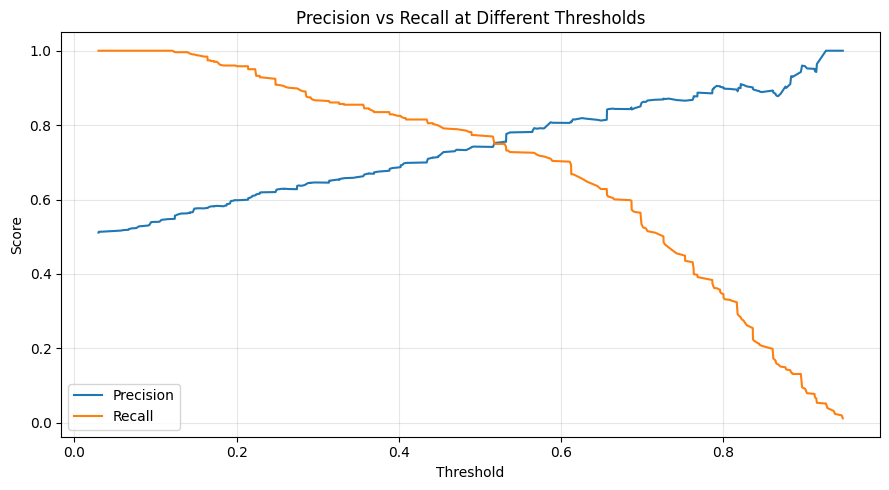


Youden's J threshold: 0.587
F2 optimal threshold: 0.148
                   Sensitivity  Specificity  Precision  Accuracy  False Positives  False Negatives
Threshold                                                                                         
Youden's J (0.59)        0.710        0.823      0.808     0.765               85              146
F2 optimal (0.15)        0.990        0.237      0.576     0.622              367                5
Default (0.50)           0.769        0.719      0.741     0.745              135              116


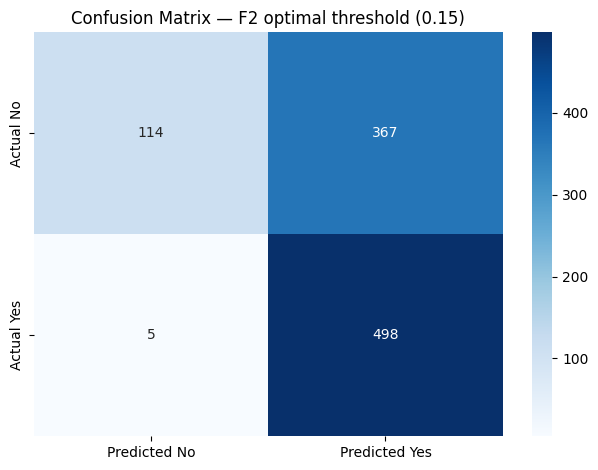

In [151]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
y_pred = lr.predict(X_test_scaled)

# Default threshold performance
print("=== Default threshold (0.50) ===")
print(f"ROC AUC:     {roc_auc_score(y_test, y_prob):.3f}")
print(f"Accuracy:    {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:   {precision_score(y_test, y_pred):.3f}")
print(f"Sensitivity: {recall_score(y_test, y_pred):.3f}")

# Precision-recall curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(9, 5))
plt.plot(pr_thresholds, precision_vals[:-1], label='Precision')
plt.plot(pr_thresholds, recall_vals[:-1],    label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Youden's J threshold
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
youden_j      = tpr - fpr
youden_thresh = roc_thresholds[np.argmax(youden_j)]

# F2 threshold — weights recall twice as heavily as precision
fbeta_scores  = [fbeta_score(y_test, (y_prob >= t).astype(int), 
                              beta=2, zero_division=0)
                 for t in pr_thresholds]
fbeta_thresh  = pr_thresholds[np.argmax(fbeta_scores)]

print(f"\nYouden's J threshold: {youden_thresh:.3f}")
print(f"F2 optimal threshold: {fbeta_thresh:.3f}")

# Side-by-side comparison table
rows = []
for label, t in {
    f"Youden's J ({youden_thresh:.2f})": youden_thresh,
    f"F2 optimal ({fbeta_thresh:.2f})":  fbeta_thresh,
    "Default (0.50)":                    0.50
}.items():
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    rows.append({
        'Threshold':       label,
        'Sensitivity':     round(cm[1,1]/(cm[1,1]+cm[1,0]), 3),
        'Specificity':     round(cm[0,0]/(cm[0,0]+cm[0,1]), 3),
        'Precision':       round(precision_score(y_test, y_pred_t), 3),
        'Accuracy':        round(accuracy_score(y_test, y_pred_t), 3),
        'False Positives': int(cm[0,1]),
        'False Negatives': int(cm[1,0])
    })

thresh_df = pd.DataFrame(rows).set_index('Threshold')
print(thresh_df.to_string())

# Apply chosen threshold and plot confusion matrix
optimal_threshold = fbeta_thresh
y_pred_final      = (y_prob >= optimal_threshold).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No',    'Actual Yes'])
plt.title(f'Confusion Matrix — F2 optimal threshold ({optimal_threshold:.2f})')
plt.tight_layout()
plt.show()

The F2 threshold is applied as the final operating point because missing a churner costs more than a false alarm in a retention context.

The final model is fully defined by these components:

**Model type:** Logistic Regression (max_iter=1000, random_state=42)

**Feature set:** The reduced set of statistically significant features identified by statsmodels p-values (p < 0.05), confirmed by the AUC comparison showing a difference below the 0.01 materiality threshold.

**Training data:** 80% of the dataset (test_size=0.2, stratify=y, random_state=42), scaled using StandardScaler fit on training data only.

**Operating threshold:** F2-optimal threshold (fbeta_thresh) — chosen because it weights recall twice as heavily as precision, reflecting that missing a churner costs more than a false retention contact.

In [153]:
print("=== Final Model Summary ===")
print(f"Model:             Logistic Regression")
print(f"Features:          {list(X_train.columns)}")
print(f"Number of features:{X_train.shape[1]}")
print(f"Training samples:  {X_train.shape[0]}")
print(f"Test samples:      {X_test.shape[0]}")
print(f"Operating threshold: {optimal_threshold:.3f} (F2 optimal)")
print(f"\nTest set performance at threshold {optimal_threshold:.3f}:")
cm = confusion_matrix(y_test, y_pred_final)
print(f"  Sensitivity:     {cm[1,1]/(cm[1,1]+cm[1,0]):.3f}")
print(f"  Specificity:     {cm[0,0]/(cm[0,0]+cm[0,1]):.3f}")
print(f"  Precision:       {precision_score(y_test, y_pred_final):.3f}")
print(f"  Accuracy:        {accuracy_score(y_test, y_pred_final):.3f}")
print(f"  ROC AUC:         {roc_auc_score(y_test, y_prob):.3f}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")

=== Final Model Summary ===
Model:             Logistic Regression
Features:          ['last_login_segment_inactive_31_60d', 'number_of_profiles', 'monthly_fee', 'payment_method_Crypto', 'last_login_segment_lapsed_8_30d', 'payment_method_Gift Card', 'favorite_genre_Romance', 'favorite_genre_Sci-Fi']
Number of features:8
Training samples:  3933
Test samples:      984
Operating threshold: 0.148 (F2 optimal)

Test set performance at threshold 0.148:
  Sensitivity:     0.990
  Specificity:     0.237
  Precision:       0.576
  Accuracy:        0.622
  ROC AUC:         0.822
  False Positives: 367
  False Negatives: 5


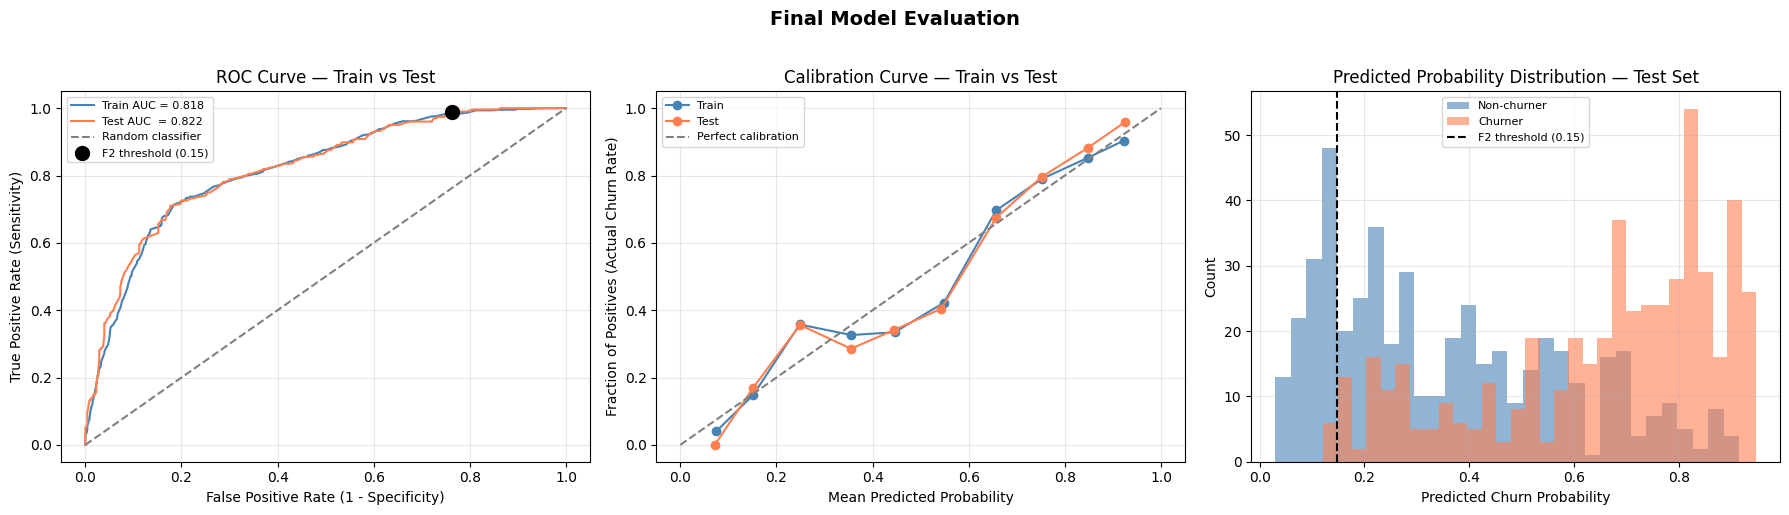

In [155]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: ROC curve — train vs test ─────────────────────────────────────────
y_prob_train = lr.predict_proba(X_train_scaled)[:, 1]
y_prob_test  = lr.predict_proba(X_test_scaled)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_prob_test)

auc_train = roc_auc_score(y_train, y_prob_train)
auc_test  = roc_auc_score(y_test,  y_prob_test)

axes[0].plot(fpr_train, tpr_train, color='steelblue',
             label=f'Train AUC = {auc_train:.3f}')
axes[0].plot(fpr_test,  tpr_test,  color='coral',
             label=f'Test AUC  = {auc_test:.3f}')
axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--',
             label='Random classifier')

# Mark F2 threshold on test curve
f2_roc_idx = np.argmin(np.abs(roc_thresholds - optimal_threshold))
axes[0].scatter(fpr[f2_roc_idx], tpr[f2_roc_idx],
                color='black', zorder=5, s=100,
                label=f'F2 threshold ({optimal_threshold:.2f})')

axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve — Train vs Test')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Plot 2: Calibration curve ─────────────────────────────────────────────────
# Shows whether predicted probabilities match actual churn rates
# A well-calibrated model follows the diagonal closely
prob_true_train, prob_pred_train = calibration_curve(
    y_train, y_prob_train, n_bins=10)
prob_true_test,  prob_pred_test  = calibration_curve(
    y_test,  y_prob_test,  n_bins=10)

axes[1].plot(prob_pred_train, prob_true_train, color='steelblue',
             marker='o', label='Train')
axes[1].plot(prob_pred_test,  prob_true_test,  color='coral',
             marker='o', label='Test')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--',
             label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives (Actual Churn Rate)')
axes[1].set_title('Calibration Curve — Train vs Test')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# ── Plot 3: Predicted probability distribution ────────────────────────────────
# Shows how well the model separates churners from non-churners
# Good separation = two distinct peaks with little overlap
axes[2].hist(y_prob_test[y_test == 0], bins=30, alpha=0.6,
             color='steelblue', label='Non-churner')
axes[2].hist(y_prob_test[y_test == 1], bins=30, alpha=0.6,
             color='coral',     label='Churner')
axes[2].axvline(optimal_threshold, color='black', linestyle='--',
                label=f'F2 threshold ({optimal_threshold:.2f})')
axes[2].set_xlabel('Predicted Churn Probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Predicted Probability Distribution — Test Set')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('Final Model Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ROC curve (left) — train and test curves sitting close together confirms the model is not overfitting. The black dot shows exactly where the F2 threshold sits on the test curve in terms of sensitivity and specificity.

Calibration curve (middle) — shows whether the model's predicted probabilities are trustworthy. If a customer is given a 70% churn probability, do roughly 70% of such customers actually churn? Points close to the diagonal mean yes. Points consistently above or below the diagonal indicate the model is systematically over or underestimating churn probability, which would be important to flag to stakeholders relying on the probability scores rather than just the binary prediction.

Probability distribution (right) — the most intuitive plot for stakeholders. Two clearly separated peaks with little overlap means the model confidently distinguishes churners from non-churners. Heavy overlap means the model is uncertain across a large portion of customers. The vertical line shows where the F2 threshold sits relative to both distributions — everything to the right of it is flagged for retention intervention.

#### **Model Coefficient Interpretation**

All coefficients are estimated on standardised features and control for all other variables in the model simultaneously.

**Login inactivity** is the strongest predictor of churn. Customers inactive for 31–60 days are 4.7× more likely to churn than recently active customers (odds ratio 4.70), while those lapsed 8–30 days have 63% higher odds (odds ratio 1.63) — making 
re-engagement the single highest-priority retention lever.

**Payment method** is the second strongest signal. Crypto (odds ratio 1.34) and Gift Card (odds ratio 1.33) customers have approximately 33–34% higher odds of churning than customers on recurring payment methods, likely reflecting lower financial commitment to the service.

**Number of profiles** (odds ratio 0.63) and **monthly fee** (odds ratio 0.66) are protective factors — each additional profile and each higher fee tier are associated with meaningfully lower churn odds, reflecting greater household embeddedness and financial investment in the service respectively.

**Favourite genre** (Romance and Sci-Fi, odds ratios 0.936 and 0.938) reached statistical significance but have negligible practical effect and should not be emphasised in retention strategy.

In [157]:
results = X_test.copy()
results['churn_probability'] = y_prob
results['actual_churn'] = y_test.values
results = results.sort_values('churn_probability', ascending=False)

high_risk_threshold = results['churn_probability'].quantile(0.90)
high_risk = results[results['churn_probability'] >= high_risk_threshold]

print(f"High risk customers (top 10%): {len(high_risk)}")
print(f"Churn probability threshold:   {high_risk_threshold:.3f}")
print(f"Actual churn rate in this group: {high_risk['actual_churn'].mean():.3f}")

High risk customers (top 10%): 102
Churn probability threshold:   0.861
Actual churn rate in this group: 0.892


In [159]:
# Find the top 5 most common feature combinations in the high risk group
key_features = [
    'last_login_segment_inactive_31_60d',
    'last_login_segment_lapsed_8_30d',
    'payment_method_Crypto',
    'payment_method_Gift Card'
]

high_risk_combos = high_risk[key_features].copy()
high_risk_combos['profiles_single'] = (high_risk['number_of_profiles'] <= 2).astype(int)
high_risk_combos['fee_low'] = (high_risk['monthly_fee'] <= 8.99).astype(int)
high_risk_combos['churn_probability'] = high_risk['churn_probability'].values

group_cols = key_features + ['profiles_single', 'fee_low']

# Count combinations and compute mean churn probability per combination
top_combos = (high_risk_combos
              .groupby(group_cols)
              .agg(
                  count=('churn_probability', 'count'),
                  mean_churn_prob=('churn_probability', 'mean')
              )
              .reset_index()
              .sort_values('count', ascending=False)
              .head(5))

top_combos['pct_of_high_risk'] = (top_combos['count'] / len(high_risk) * 100).round(1)
top_combos['mean_churn_prob'] = top_combos['mean_churn_prob'].round(3)

# Replace binary flags with readable labels
top_combos_readable = pd.DataFrame({
    'Login Status':       top_combos.apply(
        lambda r: 'Inactive 31-60d' if r['last_login_segment_inactive_31_60d'] == 1
                  else ('Lapsed 8-30d' if r['last_login_segment_lapsed_8_30d'] == 1
                  else 'Active <7d'), axis=1),
    'Payment Method':     top_combos.apply(
        lambda r: 'Crypto' if r['payment_method_Crypto'] == 1
                  else ('Gift Card' if r['payment_method_Gift Card'] == 1
                  else 'Other'), axis=1),
    'Profiles':           top_combos['profiles_single'].map(
        {1: '1-2 profiles', 0: '3+ profiles'}),
    'Fee Tier':           top_combos['fee_low'].map(
        {1: 'Low (£8.99)', 0: 'Mid/High (£13.99+)'}),
    'Count':              top_combos['count'],
    '% of High Risk':     top_combos['pct_of_high_risk'].astype(str) + '%',
    'Avg Churn Prob':     top_combos['mean_churn_prob']
})

print("\nTop 5 Highest Risk Customer Combinations:")
print("=" * 85)
print(top_combos_readable.to_string(index=False))


Top 5 Highest Risk Customer Combinations:
   Login Status Payment Method     Profiles    Fee Tier  Count % of High Risk  Avg Churn Prob
Inactive 31-60d      Gift Card 1-2 profiles Low (£8.99)     38          37.3%           0.903
Inactive 31-60d         Crypto 1-2 profiles Low (£8.99)     32          31.4%           0.915
Inactive 31-60d          Other 1-2 profiles Low (£8.99)     25          24.5%           0.892
Inactive 31-60d      Gift Card  3+ profiles Low (£8.99)      4           3.9%           0.868
Inactive 31-60d         Crypto  3+ profiles Low (£8.99)      3           2.9%           0.871


The % of High Risk represents the proportion of the high-risk group (top 10% of predicted churn probabilities) that shares that specific combination of features.
For example, the top row shows "Inactive 31-60d / Crypto / 1-2 profiles / Low fee — 37.3%", it means 37.3% of all customers in the high-risk group have exactly that combination of characteristics. It does not mean 37.3% of customers with that combination will churn; this is  captured in the AVG Churn column.

### Retention Strategy and Priority Actions

**Priority tier 1** - Customers who have not logged in for 31–60 days are the single highest churn risk in the model. An odds ratio of 4.70 means they are nearly 5 times more likely to churn than customers who logged in within the last 7 days. This is the most actionable signal because it is observable in real time and precedes cancellation.
**Recommended action:** Trigger an automated re-engagement campaign for any customer who has not logged in for 30+ days — personalised content recommendations, a reminder of what is new on the platform, or a temporary discount offer.

**Priority tier 2** - Customers who lapsed 8–30 days ago have 63% higher odds of churning than recently active customers. This group is the early warning cohort: they have not yet reached the critical inactivity threshold but are trending toward it.
**Recommended action:** Flag these customers for lighter-touch engagement. e.g., push notifications, email newsletters, or in-app prompts before they cross into the 31–60 day inactive segment.

**Priority tier 3** - Payment method risk flag
Crypto and Gift Card customers have approximately 34% higher odds of churning than customers using other payment methods. These customers may be trialling the service without a recurring payment commitment.
**Recommended action:** At or near the end of a gift card or crypto payment period, proactively prompt conversion to a recurring payment method with an incentive.

**Protective factors to leverage:** More profiles: Each additional profile reduces churn odds by ~37%. Customers using only one profile should be prompted to add family or household members, as multi-profile accounts are substantially stickier
Higher subscription tier — premium subscribers churn at lower rates. Consider whether a targeted upgrade offer to mid-tier customers could reduce churn while increasing revenue simultaneously                                           